In [1]:
from GeoEntityModel import GeoEntityModel
import torch, math
from torch.optim import AdamW
from transformers import get_cosine_schedule_with_warmup
from GeoUtils import collator, GeoDataset
from torch.utils.data import DataLoader
from globals import ID2LABEL_GEONER, LABEL2ID_GEONER

d:\GeoTKG\venv\Lib\site-packages\huggingface_hub\file_download.py:945: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


In [2]:
cleandata_path = "D:\\GeoTKG\\cleandata\\geo\\"
train = GeoDataset(cleandata_path + "train.json")
eval = GeoDataset(cleandata_path + "eval.json")
train_loader = DataLoader(train, batch_size=8, shuffle=True, collate_fn=collator)
eval_loader = DataLoader(eval, batch_size=8, shuffle=False, collate_fn=collator)

In [ ]:
NUM_EPOCHS = 15
ENC_LR = 5e-5
NONENC_LR = 1e-3
WARMUP_EPOCHS = 1
EVALUATION_EPOCHS = 1
ENC_MODEL = "roberta-large"
WEIGHT_DECAY = 0.01

In [4]:
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

model = GeoEntityModel(base=ENC_MODEL).to(device)
for p in model.enc.parameters(): p.requires_grad = False

optimizer = AdamW([
        {"params": [p for n,p in model.named_parameters() if n.startswith("enc.")], "lr": ENC_LR},
        {"params": [p for n,p in model.named_parameters() if not n.startswith("enc.")], "lr": NONENC_LR},
    ], weight_decay=0.01)

steps_per_epoch = len(train_loader)
num_train_steps = steps_per_epoch * NUM_EPOCHS
num_warmup_steps = steps_per_epoch * NUM_EPOCHS * 0.06

sched = get_cosine_schedule_with_warmup(optimizer, num_warmup_steps, num_train_steps)

scaler = torch.amp.GradScaler(enabled=(device.type=='cuda'))

def make_optim(unfrozen: bool):
    groups = []
    if unfrozen:
        groups.append({"params": model.enc.parameters(), "lr": ENC_LR})
    else:
        # keep enc group empty or skip entirely; either is fine
        pass
    nonenc = [p for n, p in model.named_parameters() if not n.startswith("enc.")]
    groups.append({"params": nonenc, "lr": NONENC_LR})
    return AdamW(groups, weight_decay=WEIGHT_DECAY)

Some weights of the model checkpoint at roberta-large were not used when initializing RobertaModel: ['lm_head.layer_norm.weight', 'lm_head.dense.weight', 'lm_head.bias', 'lm_head.dense.bias', 'lm_head.layer_norm.bias']
- This IS expected if you are initializing RobertaModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing RobertaModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [5]:
global_step = 0
history = {"loss": [], "f1": [], "eval_loss":[], "lr": []}
for epoch in range(NUM_EPOCHS):
    model.train()
    epoch_loss = 0

    for step, batch in enumerate(train_loader):
        batch = {k: (v.to(device) if torch.is_tensor(v) else v) for k, v in batch.items()}

        optimizer.zero_grad(set_to_none=True)

        with torch.autocast(device_type='cuda', dtype=torch.float16):
            out = model(
                input_ids=batch["input_ids"],
                attention_mask=batch["attention_mask"],
                labels=batch["ner_labels"],
            )
            loss = out["loss"]

        scaler.scale(loss).backward()

        # Unscale before clipping, then clip
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        # Optimizer step guarded by scaler
        scale_before = scaler.get_scale()
        scaler.step(optimizer)
        scaler.update()
        # Step scheduler ONLY if optimizer actually stepped (no inf/NaN)
        sched.step() if scaler.get_scale() <= scale_before else None

        epoch_loss += loss.item()
        global_step += 1

    print(f"EPOCH {epoch+1} Avg LOSS: {epoch_loss / steps_per_epoch:.4f}")
    history["loss"].append(epoch_loss/steps_per_epoch)
    # ---- unfreeze after warmup epochs ----
    if epoch + 1 == WARMUP_EPOCHS:
        for p in model.enc.parameters():
            p.requires_grad = True
        # rebuild optimizer & scheduler for the remaining steps
        optimizer = make_optim(unfrozen=True)
        remaining_steps = steps_per_epoch * (NUM_EPOCHS - (epoch + 1))
        warmup_rem = 0 
        sched = get_cosine_schedule_with_warmup(optimizer, warmup_rem, remaining_steps)

    # ---- validation ----
    if (epoch + 1) % EVALUATION_EPOCHS == 0:
        model.eval()
        with torch.no_grad():
            batch_evaluation = model.evaluate_dataloader(eval_loader)
        history["f1"].append(batch_evaluation["f1"])
        history["eval_loss"].append(batch_evaluation["eval_loss"])
        history["lr"].append(optimizer.param_groups[0]["lr"])
        model.save(f"results/geo_model/large_geo_epoch{epoch+1}.pt")
        print(f"EPOCH{epoch+1}: F1={batch_evaluation['f1']:.4f}, Train Loss={epoch_loss/steps_per_epoch:.4f}, Eval Loss={batch_evaluation['eval_loss']:.4f}")

d:\GeoTKG\venv\Lib\site-packages\torch\optim\lr_scheduler.py:182: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  warnings.warn(


EPOCH 1 Avg LOSS: 0.3555
              precision    recall  f1-score   support

    LOCATION     0.3997    0.2475    0.3057      1006
     MINERAL     0.6961    0.7837    0.7373      1327
 ORE_DEPOSIT     0.5836    0.5196    0.5497       383
        ROCK     0.5240    0.5755    0.5486      1894
       STRAT     0.1311    0.0841    0.1025       642
   TIMESCALE     0.9259    0.9524    0.9390       210

   micro avg     0.5482    0.5185    0.5329      5462
   macro avg     0.5434    0.5271    0.5305      5462
weighted avg     0.5164    0.5185    0.5124      5462

EPOCH1: F1=0.5329, Train Loss=0.3555, Eval Loss=0.2642
EPOCH 2 Avg LOSS: 0.0773
              precision    recall  f1-score   support

    LOCATION     0.5583    0.5189    0.5379      1006
     MINERAL     0.8193    0.9156    0.8648      1327
 ORE_DEPOSIT     0.8732    0.7728    0.8199       383
        ROCK     0.7588    0.7724    0.7656      1894
       STRAT     0.8011    0.6776    0.7342       642
   TIMESCALE     0.9529    

In [10]:
model.save("results/geo_model/geo_model_test.pt")

In [7]:
import json
with open("results/geo_model/history.json", "w") as f:
    json.dump(history, f, indent=2)

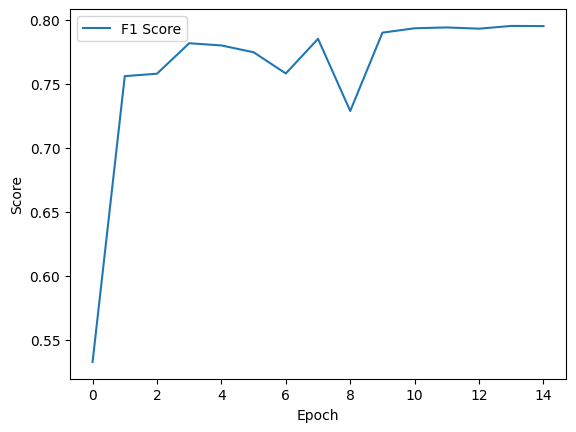

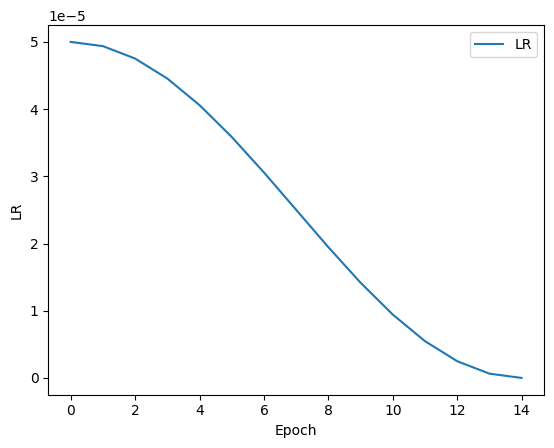

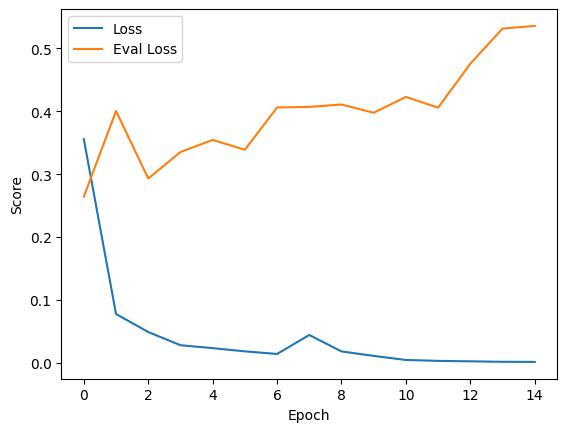

In [9]:
import matplotlib.pyplot as plt

plt.plot(history["f1"], label="F1 Score")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.legend()
plt.show()

plt.plot(history["lr"], label="LR")
plt.xlabel("Epoch")
plt.ylabel("LR")
plt.legend()
plt.show()

plt.plot(history["loss"], label="Loss")
plt.plot(history["eval_loss"], label="Eval Loss")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.legend()
plt.show()